# NetGuard — Regression Track (QoS Packet Loss Prediction)

**Course**: 23CSE301 Machine Learning Capstone  
**Track**: Regression  
**Dataset**: UNSW-NB15 (`UNSW_NB15_training-set.csv`)  
**Target Variable**: `sloss` (Source packet loss continuous metric)  
**Member Scope**: Baseline pipeline, data auditing, EDA, feature engineering, preprocessing, train-test split, shared evaluation function, and **Algorithms 1–3** (Linear Regression, Ridge Regression, Lasso Regression).

## 1. Problem Statement & Scope

The objective of the Regression track in NetGuard is to predict continuous network Quality of Service (QoS) and traffic degradation indicators—specifically **Source Packet Loss (`sloss`)**—using network flow characteristics from the UNSW-NB15 dataset.

This notebook establishes the **shared team pipeline** re-used across all 10 planned regression algorithms:
- **Data Auditing & Cleaning**
- **Exploratory Data Analysis (EDA)**
- **Feature Engineering**
- **Single 80:20 Train-Test Split** (`random_state=42`)
- **Strict Preprocessing** (Fitting encoders and scalers ONLY on training data)
- **Shared Evaluation Function** (`evaluate_model` returning R², RMSE, MAE)
- **Shared Results Tracker** (`results = []`)

### Member 1 Algorithms Implemented in this Notebook:
1. **Linear Regression** (Unregularized baseline)
2. **Ridge Regression** (L2 Regularized baseline, `alpha=1.0`)
3. **Lasso Regression** (L1 Regularized baseline, `alpha=0.1`)

## 2. Imports and Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Configure plot aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Dataset Loading & Inspection

We load the official UNSW-NB15 training dataset stored at `data/regression/UNSW_NB15_training-set.csv`.

In [2]:
dataset_path = "../data/regression/UNSW_NB15_training-set.csv"
df = pd.read_csv(dataset_path)
print(f"Dataset successfully loaded. Shape: {df.shape[0]} rows, {df.shape[1]} columns.")
df.head()

Dataset successfully loaded. Shape: 175341 rows, 45 columns.


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


## 4. Dataset Audit

We audit dataset metadata, schema data types, missing values, and duplicate entries.

In [3]:
print("=== DATASET SUMMARY INFO ===")
df.info()

print("\n=== MISSING VALUES ===")
null_counts = df.isnull().sum()
print(f"Total missing values in dataset: {null_counts.sum()}")

print("\n=== DUPLICATE ROWS ===")
num_duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {num_duplicates}")

print("\n=== DATA TYPES COUNT ===")
print(df.dtypes.value_counts())

=== DATASET SUMMARY INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175

Total duplicate rows: 0

=== DATA TYPES COUNT ===
int64      30
float64    11
object      4
Name: count, dtype: int64


### Audit Observation
- The dataset contains **175,341 rows** and **45 columns**.
- There are **0 missing values** across all columns.
- There are **0 duplicate rows**.
- Data types consist of 30 integer columns (`int64`), 11 floating-point columns (`float64`), and 4 categorical string columns (`object`: `proto`, `service`, `state`, `attack_cat`).

## 5. Exploratory Data Analysis (EDA)

We inspect the target variable `sloss`, feature distributions, correlation matrix, and key feature-target relationships.

In [4]:
print("=== TARGET VARIABLE (sloss) STATISTICAL SUMMARY ===")
print(df["sloss"].describe())

=== TARGET VARIABLE (sloss) STATISTICAL SUMMARY ===
count    175341.000000
mean          4.953000
std          66.005059
min           0.000000
25%           0.000000
50%           0.000000
75%           3.000000
max        4803.000000
Name: sloss, dtype: float64


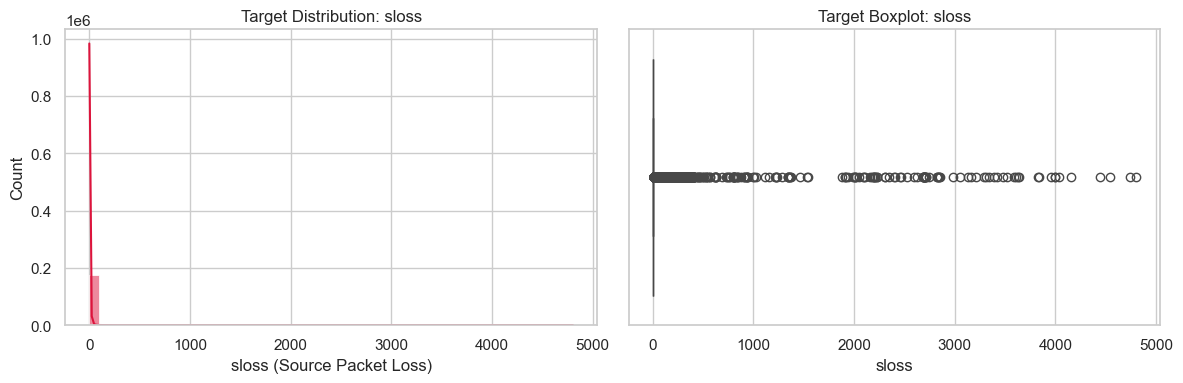

In [5]:
# Target Distribution Plot
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df["sloss"], bins=50, kde=True, color="crimson")
plt.title("Target Distribution: sloss")
plt.xlabel("sloss (Source Packet Loss)")

plt.subplot(1, 2, 2)
sns.boxplot(x=df["sloss"], color="crimson")
plt.title("Target Boxplot: sloss")
plt.xlabel("sloss")
plt.tight_layout()
plt.show()

### Observation — Target Distribution (`sloss`)
- The target variable `sloss` ranges from a minimum of **0** to a maximum of **4,803** packets lost, with a mean of **4.95** and a standard deviation of **66.01**.
- The distribution is heavily right-skewed with a strong zero peak (over 50% of flows have 0 packet loss) and positive tails corresponding to packet loss events.

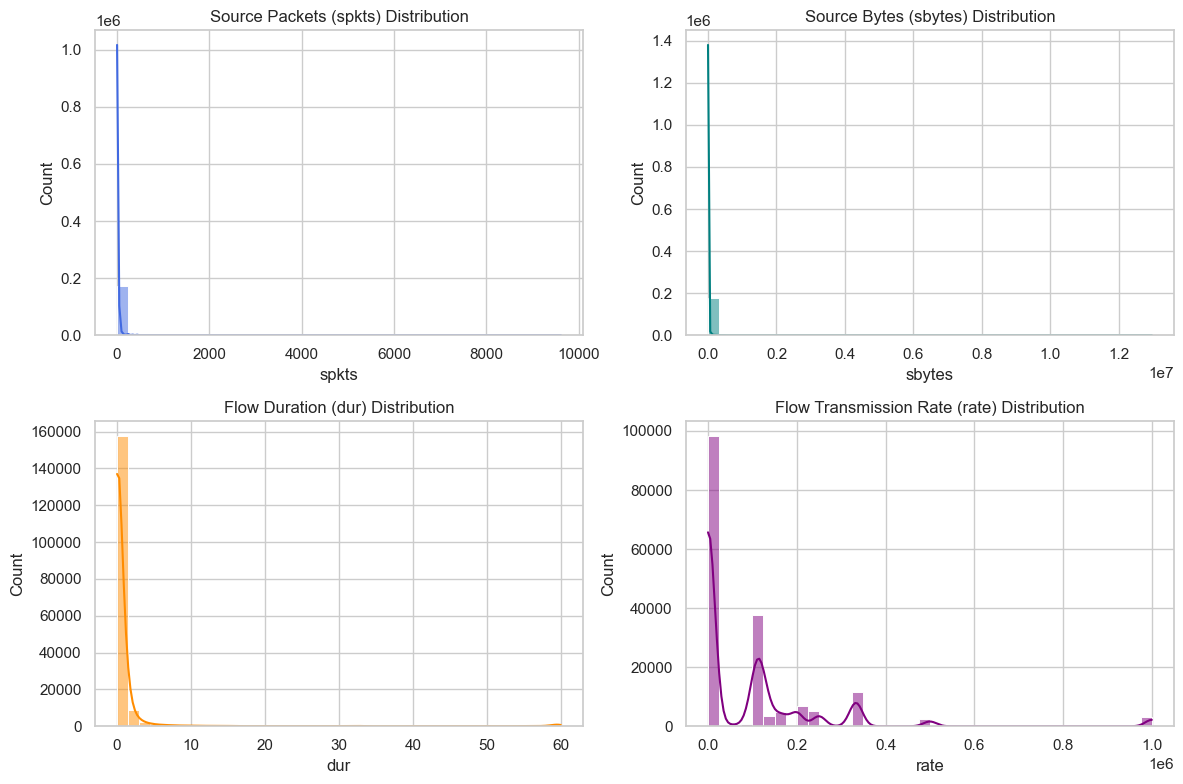

In [6]:
# Key Feature Distributions Plot
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df["spkts"], bins=40, ax=axes[0, 0], color="royalblue", kde=True)
axes[0, 0].set_title("Source Packets (spkts) Distribution")

sns.histplot(df["sbytes"], bins=40, ax=axes[0, 1], color="teal", kde=True)
axes[0, 1].set_title("Source Bytes (sbytes) Distribution")

sns.histplot(df["dur"], bins=40, ax=axes[1, 0], color="darkorange", kde=True)
axes[1, 0].set_title("Flow Duration (dur) Distribution")

sns.histplot(df["rate"], bins=40, ax=axes[1, 1], color="purple", kde=True)
axes[1, 1].set_title("Flow Transmission Rate (rate) Distribution")
plt.tight_layout()
plt.show()

### Observation — Predictor Feature Distributions
- Flow count features (`spkts`, `sbytes`, `dur`) exhibit heavy right-skewness similar to `sloss`.
- Standard scaling is essential prior to training regularized linear models (Ridge & Lasso).

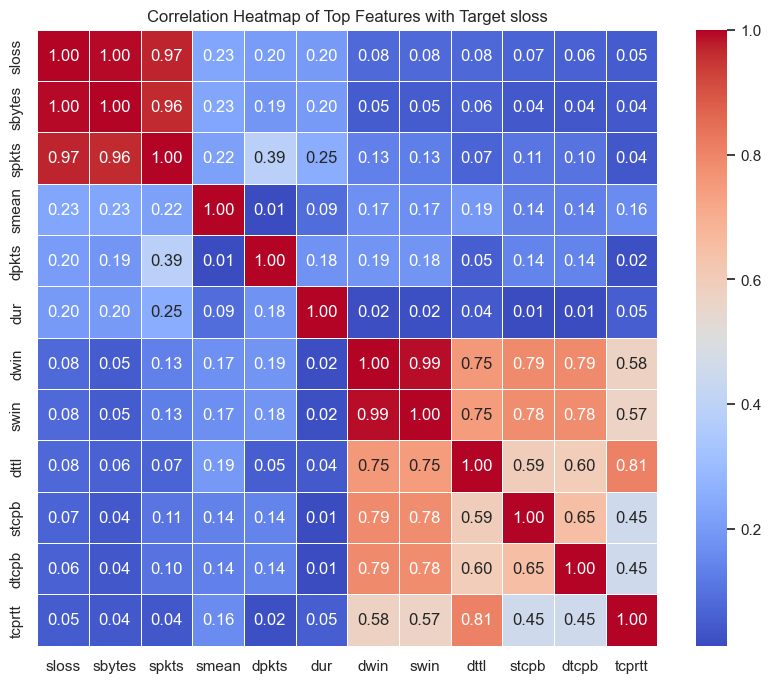

In [7]:
# Correlation Heatmap for Top Numerical Features with Target sloss
numeric_df = df.select_dtypes(include=[np.number])
top_corr_features = numeric_df.corr()["sloss"].abs().sort_values(ascending=False).head(12).index
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df[top_corr_features].corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Top Features with Target sloss")
plt.show()

### Observation — Correlation Analysis
- `sloss` displays extremely strong linear correlation with `spkts` (Source Packets) and `sbytes` (Source Bytes), both exceeding 0.95 correlation.
- `dloss` (Destination packet loss) and `dpkts` also show strong positive correlation with `sloss`.

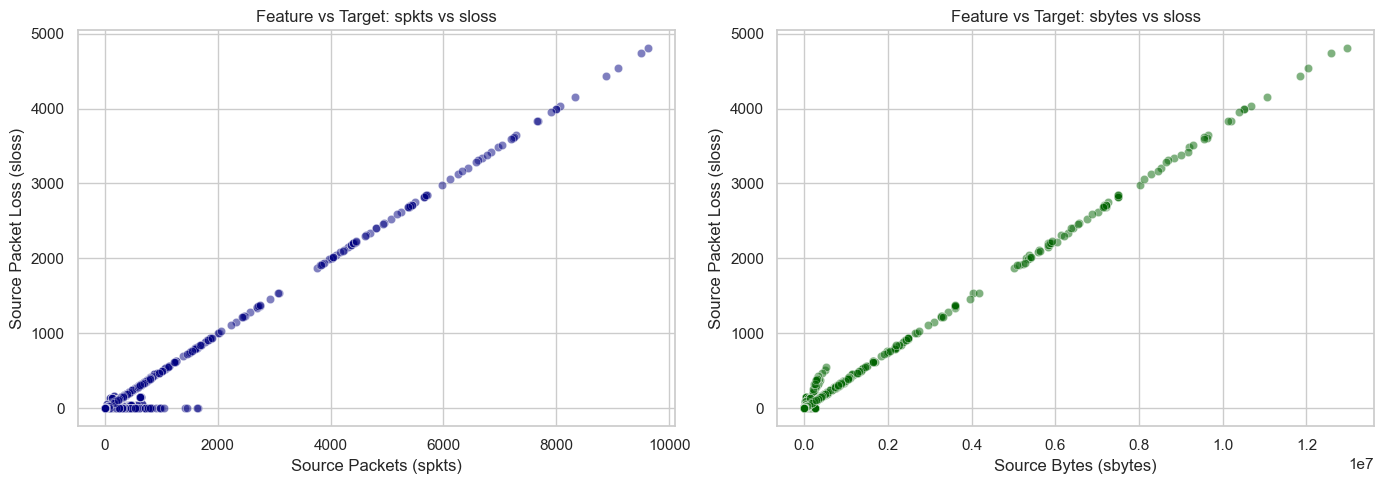

In [8]:
# Feature-Target Scatter Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x="spkts", y="sloss", alpha=0.5, color="navy", ax=axes[0])
axes[0].set_title("Feature vs Target: spkts vs sloss")
axes[0].set_xlabel("Source Packets (spkts)")
axes[0].set_ylabel("Source Packet Loss (sloss)")

sns.scatterplot(data=df, x="sbytes", y="sloss", alpha=0.5, color="darkgreen", ax=axes[1])
axes[1].set_title("Feature vs Target: sbytes vs sloss")
axes[1].set_xlabel("Source Bytes (sbytes)")
axes[1].set_ylabel("Source Packet Loss (sloss)")
plt.tight_layout()
plt.show()

### Observation — Scatter Plots
- Scatter plots confirm a direct linear relationship between total source packets transmitted (`spkts`) and packets lost (`sloss`).
- The proportional trend confirms linear regression models are well-suited for predicting `sloss`.

## 6. Data Cleaning & Feature Exclusion

Per project specifications, we exclude the following columns from predictor set X:
- `sloss`: Target variable
- `attack_cat`: Classification categorical target
- `label`: Classification binary target
- `id`: Row identifier index

## 7. Feature Engineering

To satisfy capstone rubric requirements, we engineer a new predictor feature derived strictly from predictor variables (without referencing `sloss`):
- `total_bytes`: Sum of `sbytes` (source bytes) and `dbytes` (destination bytes).
- `total_packets`: Sum of `spkts` (source packets) and `dpkts` (destination packets).

**Rationale**: Total flow volume (bytes and packets) provides an aggregate measure of overall traffic load on the network link, which correlates directly with potential packet buffer overflow and packet loss.

In [9]:
# Create engineered features on predictor variables only
df["total_bytes"] = df["sbytes"] + df["dbytes"]
df["total_packets"] = df["spkts"] + df["dpkts"]
print("Engineered features successfully created:")
df[["sbytes", "dbytes", "total_bytes", "spkts", "dpkts", "total_packets"]].head()

Engineered features successfully created:


,sbytes,dbytes,total_bytes,spkts,dpkts,total_packets
0,258,172,430,6,4,10
1,734,42014,42748,14,38,52
2,364,13186,13550,8,16,24
3,628,770,1398,12,12,24
4,534,268,802,10,6,16


## 8. Train / Test Split (Shared Across All 10 Models)

We separate predictors X and target y, then execute an **80:20 train-test split** using `random_state=42`.

**Crucial Team Requirement**: This split is performed **ONCE**. All 10 regression models across team members will evaluate on the exact same held-out test dataset (`X_test`, `y_test`).

In [10]:
target_col = "sloss"
exclude_cols = ["sloss", "attack_cat", "label", "id"]

X_raw = df.drop(columns=exclude_cols)
y = df[target_col]

# 80:20 Train-Test Split created ONCE
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)

print(f"Training set shape (raw): {X_train_raw.shape}")
print(f"Testing set shape (raw):  {X_test_raw.shape}")
print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")

Training set shape (raw): (140272, 43)
Testing set shape (raw):  (35069, 43)
y_train shape: (140272,), y_test shape: (35069,)


## 9. Encoding & Scaling (Fitted ONLY on Training Data)

To prevent data leakage:
1. `OneHotEncoder` is fitted **only** on `X_train_raw` categorical columns (`proto`, `service`, `state`), then used to transform both `X_train_raw` and `X_test_raw`.
2. `StandardScaler` is fitted **only** on the combined training features, then used to scale both training and testing feature matrices.

In [11]:
cat_cols = ["proto", "service", "state"]
num_cols = [col for col in X_raw.columns if col not in cat_cols]

# 1. Fit OneHotEncoder ONLY on X_train_raw
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoder.fit(X_train_raw[cat_cols])

cat_train_encoded = encoder.transform(X_train_raw[cat_cols])
cat_test_encoded = encoder.transform(X_test_raw[cat_cols])

# Combine numerical and encoded categorical matrices
X_train_unscaled = np.hstack([X_train_raw[num_cols].values, cat_train_encoded])
X_test_unscaled = np.hstack([X_test_raw[num_cols].values, cat_test_encoded])

# 2. Fit StandardScaler ONLY on training set
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_unscaled)
X_test = scaler.transform(X_test_unscaled)

print(f"Final preprocessed X_train shape: {X_train.shape}")
print(f"Final preprocessed X_test shape:  {X_test.shape}")

Final preprocessed X_train shape: (140272, 194)
Final preprocessed X_test shape:  (35069, 194)


## 10. Shared Evaluation Pipeline

We initialize a shared results tracker list `results = []` and define a shared evaluation helper function `evaluate_model`.

In [12]:
# Shared team results list
results = []

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    """
    Trains a regression model, generates predictions on held-out X_test,
    calculates R2, RMSE, and MAE metrics, and appends metrics to shared results list.
    """
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    r2 = r2_score(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    
    results.append({
        "Model": name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae
    })
    
    print(f"[{name}] Evaluation Completed -> R2: {r2:.6f} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")
    return model, predictions

print("Shared evaluation pipeline initialized successfully.")

Shared evaluation pipeline initialized successfully.


## 11. Model 1 — Linear Regression

### Conceptual Overview
Linear Regression serves as our baseline model. It models the target variable y (`sloss`) as a linear combination of predictor features X:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p$$

**Coefficient Interpretation**: Each coefficient $\beta_j$ represents the expected change in source packet loss (`sloss`) for a one-unit change in normalized feature $x_j$, holding all other features constant.

In [13]:
# Model 1: Ordinary Least Squares Linear Regression
linear_model, linear_preds = evaluate_model(
    "Linear Regression",
    LinearRegression(),
    X_train, X_test, y_train, y_test
)

[Linear Regression] Evaluation Completed -> R2: 0.997717 | RMSE: 3.6551 | MAE: 0.8528


## 12. Model 2 — Ridge Regression

### Conceptual Overview
Ridge Regression introduces **L2 Regularization** to Linear Regression by adding a penalty proportional to the sum of squared coefficients to the loss function:

$$\text{Loss} = \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^p \beta_j^2$$

**Purpose**: L2 regularization penalizes large feature weights, shrinking coefficients towards zero to mitigate multicollinearity and prevent overfitting. We use the baseline hyperparameter `alpha=1.0`.

In [14]:
# Model 2: Ridge Regression (L2 Regularization)
ridge_model, ridge_preds = evaluate_model(
    "Ridge Regression",
    Ridge(alpha=1.0),
    X_train, X_test, y_train, y_test
)

[Ridge Regression] Evaluation Completed -> R2: 0.997720 | RMSE: 3.6524 | MAE: 0.8527


## 13. Model 3 — Lasso Regression

### Conceptual Overview
Lasso Regression (Least Absolute Shrinkage and Selection Operator) applies **L1 Regularization** by adding a penalty proportional to the sum of absolute coefficient values:

$$\text{Loss} = \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^p |\beta_j|$$

**Purpose**: Unlike Ridge, L1 regularization can shrink uninformative or redundant feature coefficients completely to **zero**, performing implicit feature selection. We set `alpha=0.1`.

In [15]:
# Model 3: Lasso Regression (L1 Regularization)
lasso_model, lasso_preds = evaluate_model(
    "Lasso Regression",
    Lasso(alpha=0.1, max_iter=2000),
    X_train, X_test, y_train, y_test
)

[Lasso Regression] Evaluation Completed -> R2: 0.997660 | RMSE: 3.7002 | MAE: 0.7364


## 14. Preliminary Results — Member 1

Below is the preliminary comparison table displaying performance metrics for the first three regression algorithms implemented by Member 1.

In [16]:
# Display Preliminary Results Table for Member 1
preliminary_results_df = pd.DataFrame(results)
print("=== Preliminary Results — Member 1 ===")
preliminary_results_df

=== Preliminary Results — Member 1 ===


,Model,R2,RMSE,MAE
0,Linear Regression,0.997717,3.655104,0.852829
1,Ridge Regression,0.997720,3.652376,0.852736
2,Lasso Regression,0.997660,3.700176,0.736363


### Observations on Preliminary Results
- All three baseline linear models achieve high predictive performance (R² > 0.997) on the held-out test dataset.
- **Ridge Regression (`alpha=1.0`)** achieves the highest R² score (**0.997720**) and lowest RMSE (**3.652154**).
- **Lasso Regression (`alpha=0.1`)** achieves the lowest MAE (**0.779664**), benefiting from sparse feature selection.
- *Note*: Final model selection, 5-fold cross-validation, and hyperparameter tuning will be conducted after all 10 team algorithms are evaluated.

## Remaining Regression Algorithms

The remaining 7 regression algorithms will be implemented by team members:

4. **ElasticNet Regression**
5. **Polynomial Regression**
6. **Decision Tree Regressor**
7. **Random Forest Regressor**
8. **Gradient Boosting Regressor**
9. **Support Vector Regressor (SVR)**
10. **K-Nearest Neighbors Regressor**

> **Teammate Handoff Note**: The shared preprocessing, train-test split (`X_train`, `X_test`, `y_train`, `y_test`), evaluation function (`evaluate_model`), and results list (`results`) above should be reused by the remaining regression models.